# Step 3: Make your classifier

### Background
Transcription factors are proteins that bind DNA at promoters to drive gene expression. Most preferentially bind to specific sequences while ignoring others. Traditional methods to determine these sequences (called motifs) have assumed that binding sites in the genome are all independent. However, in some cases people have identified motifs where positional interdependencies exist.

### Your task
You will implement a multi-layer fully connected neural network using your NeuralNetwork class to predict whether a short DNA sequence is a binding site for the yeast transcription factor Rap1. The training data is incredibly imbalanced, with way fewer positive sequences than negative sequences, so you will implement a sampling scheme to ensure that class imbalance does not affect training. As in step 2, all of the following work should be done in a Jupyter Notebook.

### To-do
* Use the read_text_file function from io.py to read in the 137 positive Rap1 motif examples.
* Use the read_fasta_file function from io.py to read in all the negative examples. Note that these sequences are much longer than the positive sequences, so you will need to process them to the same length.
* Balance your classes using your sample_seq function and explain why you chose the sampling scheme you did.
* One-hot encode the data using your one_hot_encode_seqs function.
* Split the data into training and validation sets.
* Generate an instance of your NeuralNetwork class with an appropriate architecture.
* Train your neural network on the training data.
* Plot your training and validation loss by epoch.
* Report the accuracy of your classifier on your validation dataset.
* Explain your choice of loss function and hyperparameters.

## Initial imports

In [1]:
# import my NeuralNetwork class, and io/preprocess functions
from nn.nn import NeuralNetwork
from nn.io import read_text_file, read_fasta_file
from nn.preprocess import sample_seqs, one_hot_encode_seqs

# import sklearn utilities for data loading and splitting
from sklearn.model_selection import train_test_split

# import numpy for calculations
import numpy as np

# import matplotlib for visualization
import matplotlib.pyplot as plt

## Load and prepare the positive and negative data

In [2]:
# load the positive and negative data
pos_seqs = read_text_file("data/rap1-lieb-positives.txt")
neg_seqs = read_fasta_file("data/yeast-upstream-1k-negative.fa")
print(f"Number of positive sequences: {len(pos_seqs)}")
print(f"Number of negative sequences: {len(neg_seqs)}")

# trim the negative sequences to the same length as the longest positive sequence
max_pos_len = max(len(seq) for seq in pos_seqs)
neg_seqs = [seq[:max_pos_len] for seq in neg_seqs]
print(f"Trimmed negative sequences to length: {max_pos_len}")

# combine seqs and init labels
seqs = pos_seqs + neg_seqs
labels = [True] * len(pos_seqs) + [False] * len(neg_seqs)
print(f"Total number of sequences: {len(seqs)}")

Number of positive sequences: 137
Number of negative sequences: 3163
Trimmed negative sequences to length: 17
Total number of sequences: 3300


In [3]:
# balance the classes
sampled_seqs, sampled_labels = sample_seqs(seqs, labels)
print(f"Total sampled sequences: {len(sampled_seqs)} ({sum(sampled_labels)} positives, {len(sampled_labels) - sum(sampled_labels)} negatives)")

Total sampled sequences: 6326 (3163 positives, 3163 negatives)


In [4]:
# encode the seqs with one-hot scheme and convert to numpy array
encoded_seqs = one_hot_encode_seqs(sampled_seqs)

# convert list structure to numpy arrays
encoded_seqs = np.array(encoded_seqs)
sampled_labels = np.array(sampled_labels)
print(f"Encoded sequences shape: {encoded_seqs.shape}")
print(f"Sampled labels shape: {sampled_labels.shape}")

Encoded sequences shape: (6326, 68)
Sampled labels shape: (6326,)


In [5]:
# split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(encoded_seqs, sampled_labels, test_size=0.2, random_state=42)

# confirm data shapes are as expected
print(f"X_train shape: {X_train.shape}", f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}", f"y_val shape: {y_val.shape}")

X_train shape: (5060, 68) y_train shape: (5060,)
X_val shape: (1266, 68) y_val shape: (1266,)


## Create an instance of my NeuralNetwork class with an appropriate classifier architecture

In [6]:
# define the model architecture and hyperparameters
input_dim = X_train.shape[1]
nn_arch = [
    {'input_dim': input_dim, 'output_dim': 64, 'activation': 'relu'},
    {'input_dim': 64, 'output_dim': 64, 'activation': 'relu'},
    {'input_dim': 64, 'output_dim': 1, 'activation': 'sigmoid'}
]
lr = 1e-2
seed = 42
batch_size = 32
epochs = 100
loss_function = 'bce'

# create an instance of the classifier with the defined arguments
classifier = NeuralNetwork(
    nn_arch,
    lr,
    seed,
    batch_size,
    epochs,
    loss_function
)

## Train the classifier

In [7]:
# train the classifier and save the per epoch losses
per_epoch_loss_train, per_epoch_loss_val = classifier.fit(X_train, y_train, X_val, y_val)

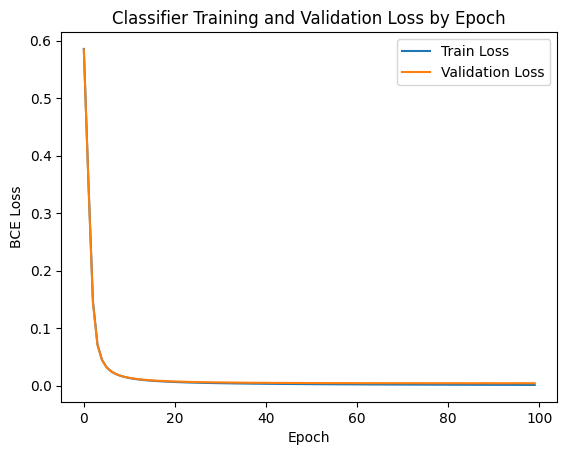

In [8]:
# display the training and validation losses by epoch
plt.plot(per_epoch_loss_train, label='Train Loss')
plt.plot(per_epoch_loss_val, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Classifier Training and Validation Loss by Epoch')
plt.legend()
plt.show()

## Classifier accuracy on the validation set

In [9]:
# predict class logits for the validation set
y_hat = classifier.predict(X_val)

# convert probabilities to binary predictions and 1D array
y_hat = (y_hat >= 0.5).flatten()

# compute and display the accuracy
accuracy = np.mean(y_hat == y_val)
print(f"Classifier accuracy on the validation set: {accuracy:.4f}")

Classifier accuracy on the validation set: 0.9984


## Explanation of hyperparameter selection

`nn_arch = `: 

`lr = `: 

`seed = 42`: this random seed was chosen to ensure reproducibility.

`batch_size = `: 

`epochs = `: 

`loss_function = 'bce'`: 